# Particle Swarm Optimization 粒子群优化

## 本 Notebook 的教学目标

1. 理解该算法的搜索直觉。
2. 使用一个经典二维优化问题完成从零实现。
3. 通过可视化观察算法如何移动、如何收敛、可能会遇到什么问题。
4. 通过多次运行和参数实验建立更稳固的算法直觉。

## 实验问题

本实验使用 **Himmelblau 函数**。粒子群算法在二维空间中的运动轨迹非常适合做课堂演示。

在教学上，二维问题有一个明显优势：**我们可以直接把搜索轨迹画出来**。这比只看一串数值更适合课堂演示。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一图表风格，保证讲课时图表更清晰。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 本项目统一使用二维测试函数，这样可以把搜索轨迹直接画在等高线上。

def make_grid(bounds, step=250):
    xs = np.linspace(bounds[0, 0], bounds[0, 1], step)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], step)
    xx, yy = np.meshgrid(xs, ys)
    return xs, ys, xx, yy


def evaluate_on_grid(objective, bounds, step=250):
    xs, ys, xx, yy = make_grid(bounds, step=step)
    zz = np.vectorize(lambda a, b: objective(np.array([a, b])))(xx, yy)
    return xs, ys, xx, yy, zz


def plot_contour_with_trace(objective, bounds, trace, title, levels=40):
    xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
    plt.figure(figsize=(9, 7))
    contour = plt.contourf(xx, yy, zz, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Objective value')

    trace = np.array(trace)
    plt.plot(trace[:, 0], trace[:, 1], color='white', lw=2, alpha=0.9, label='Search trace')
    plt.scatter(trace[:, 0], trace[:, 1], c=np.arange(len(trace)), cmap='coolwarm', s=40, edgecolor='black')
    plt.scatter(trace[0, 0], trace[0, 1], color='gold', s=120, marker='o', edgecolor='black', label='Start')
    plt.scatter(trace[-1, 0], trace[-1, 1], color='red', s=160, marker='*', edgecolor='black', label='End / Best')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


def objective(point):
    x, y = point
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

bounds = np.array([[-6, 6], [-6, 6]], dtype=float)

## 算法直觉

核心思想：每个粒子同时记住自己的历史最好位置，也会被群体历史最好位置吸引，因此会形成“个体经验 + 群体经验”的协同搜索。

为了让课堂节奏更清楚，Notebook 里的实现会优先追求**可读性**，而不是极端性能优化。

In [2]:
def particle_swarm_optimization(objective, bounds, n_particles=25, n_iterations=80, w=0.72, c1=1.6, c2=1.8, seed=0):
    rng = np.random.default_rng(seed)
    dim = len(bounds)

    positions = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_particles, dim))
    velocities = rng.normal(0, 0.6, size=(n_particles, dim))

    personal_best_positions = positions.copy()
    personal_best_scores = np.apply_along_axis(objective, 1, positions)

    global_best_idx = int(np.argmin(personal_best_scores))
    global_best_position = personal_best_positions[global_best_idx].copy()
    global_best_score = float(personal_best_scores[global_best_idx])

    position_history = [positions.copy()]
    best_scores = [global_best_score]

    for _ in range(n_iterations):
        r1 = rng.random(size=(n_particles, dim))
        r2 = rng.random(size=(n_particles, dim))

        # 速度更新由三部分组成：惯性、自我认知、社会认知。
        velocities = (
            w * velocities
            + c1 * r1 * (personal_best_positions - positions)
            + c2 * r2 * (global_best_position - positions)
        )
        positions = np.clip(positions + velocities, bounds[:, 0], bounds[:, 1])

        scores = np.apply_along_axis(objective, 1, positions)
        improved = scores < personal_best_scores
        personal_best_positions[improved] = positions[improved]
        personal_best_scores[improved] = scores[improved]

        best_idx = int(np.argmin(personal_best_scores))
        if personal_best_scores[best_idx] < global_best_score:
            global_best_score = float(personal_best_scores[best_idx])
            global_best_position = personal_best_positions[best_idx].copy()

        position_history.append(positions.copy())
        best_scores.append(global_best_score)

    return {
        'best': global_best_position,
        'best_score': global_best_score,
        'position_history': position_history,
        'best_scores': np.array(best_scores),
    }

## 单次实验演示

下面先运行一次实验，重点观察两件事：

1. 搜索轨迹是否平滑、是否容易停在局部区域。
2. 目标值是否快速下降，以及下降到什么程度后开始停滞。

best point: [-3.7794 -3.2833]
best score: 0.0


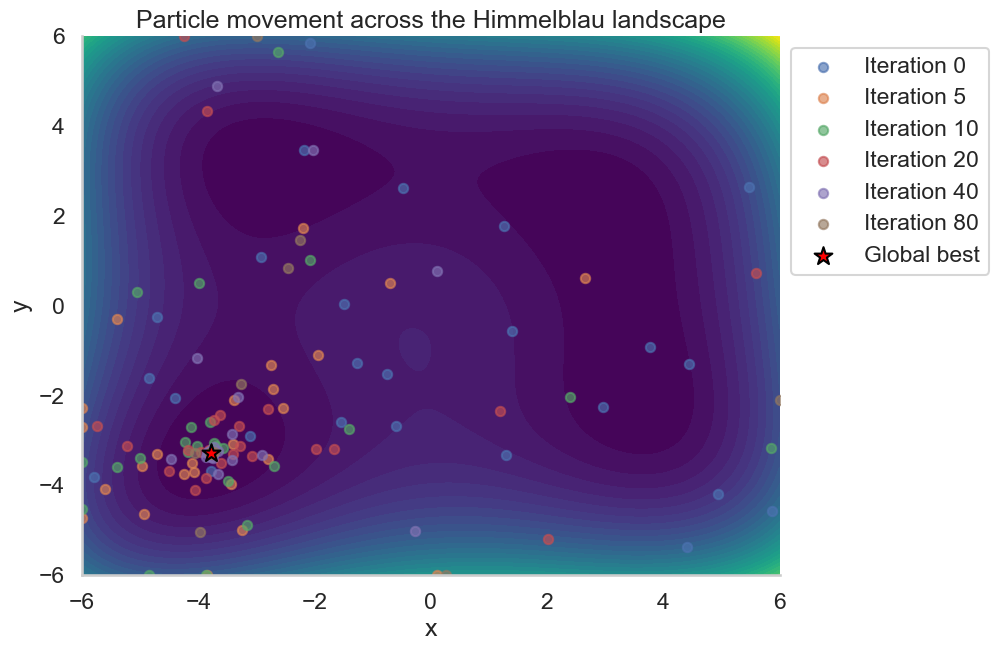

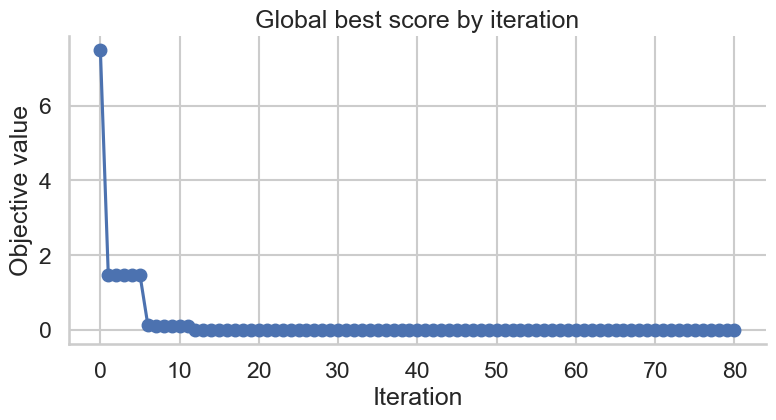

In [3]:
pso_result = particle_swarm_optimization(objective, bounds, seed=8)
print('best point:', np.round(pso_result['best'], 4))
print('best score:', round(pso_result['best_score'], 6))

xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, zz, levels=40, cmap='viridis')
for idx in [0, 5, 10, 20, 40, 80]:
    swarm = pso_result['position_history'][idx]
    plt.scatter(swarm[:, 0], swarm[:, 1], s=45, alpha=0.65, label=f'Iteration {idx}')
plt.scatter(pso_result['best'][0], pso_result['best'][1], color='red', s=180, marker='*', edgecolor='black', label='Global best')
plt.title('Particle movement across the Himmelblau landscape')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(pso_result['best_scores'], marker='o')
plt.title('Global best score by iteration')
plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.show()

## 多次运行与参数分析

单次实验只能告诉我们“这一次发生了什么”，但讲课时更重要的是说明：

1. 算法是否稳定。
2. 算法是否依赖初始条件。
3. 关键参数变化后，会如何影响最终表现。

,PSO statistics
best,2.378670e-09
mean,2.812619e-07
worst,2.031343e-06
std,4.989538e-07


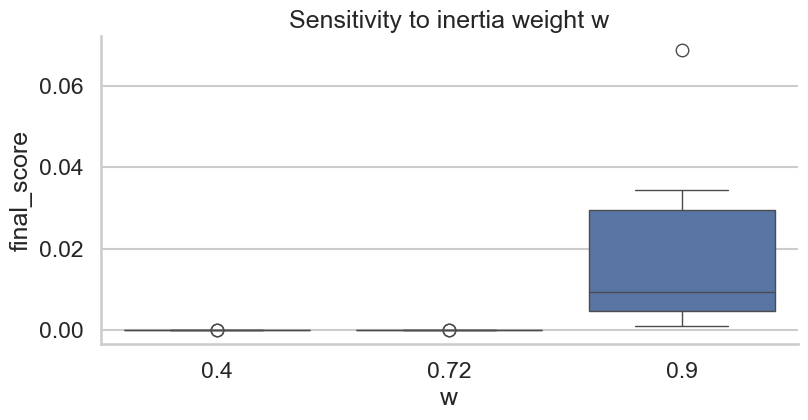

In [4]:
run_scores = [particle_swarm_optimization(objective, bounds, seed=seed)['best_score'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='PSO statistics'))

w_values = [0.4, 0.72, 0.9]
records = []
for w in w_values:
    for seed in range(10):
        score = particle_swarm_optimization(objective, bounds, w=w, seed=seed)['best_score']
        records.append({'w': w, 'final_score': score})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='w', y='final_score')
plt.title('Sensitivity to inertia weight w')
plt.show()

## 课堂总结

讲解这一类算法时，建议把重点放在以下问题上：

1. 算法的探索能力来自哪里。
2. 算法的利用能力来自哪里。
3. 它最容易失败的场景是什么。
4. 参数变化时，算法行为为什么会改变。

把这四个问题讲清楚，学生通常就能真正建立算法直觉。